<a href="https://colab.research.google.com/github/FrancescoPassiatore/ObjectDetection-Camera-Lidar-fusion/blob/main/object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset definition

In [ ]:
%%bash
# For v1.0 version of mini dataset
wget https://man-truckscenes.s3.eu-central-1.amazonaws.com/release/mini/man-truckscenes_metadata_v1.0-mini.zip
wget https://man-truckscenes.s3.eu-central-1.amazonaws.com/release/mini/man-truckscenes_sensordata_v1.0-mini.zip
unzip "man-truckscenes_*.zip"

In [ ]:
!pip install ultralytics
!pip install truckscenes-devkit[all]

In [ ]:
from truckscenes import TruckScenes

trucksc = TruckScenes('v1.0-mini', '/content/man-truckscenes', True)


# Imports

In [ ]:
from ultralytics import YOLO
from IPython.display import display, Image
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import cv2
import torch
import numpy as np
import os
from ultralytics.utils.benchmarks import benchmark


In [ ]:
import os
import os.path as osp

from datetime import datetime
from typing import Dict, List, Tuple, Union

import cv2
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d

from PIL import Image
from matplotlib import cm, rcParams
from matplotlib.axes import Axes
from matplotlib.colors import Colormap, Normalize
from matplotlib.cm import ScalarMappable
from pyquaternion import Quaternion

from truckscenes.utils import colormap
from truckscenes.utils.data_classes import LidarPointCloud, RadarPointCloud
from truckscenes.utils.geometry_utils import view_points, transform_matrix, \
    BoxVisibility

from matplotlib.patches import Rectangle


# YOLO vs Ground Truth

First inference with YOLO, labels are mapped to the known COCO dataset.If no label is present , it is mapped to -1.
This script generates the results of the inference and the rendered images with the ground truth annotations (red) and the YOLO predictions (green).

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.axes import Axes
from typing import List, Tuple, Union
from PIL import Image
from matplotlib import cm
from matplotlib.colors import Colormap
from truckscenes.utils.geometry_utils import BoxVisibility

from collections import defaultdict

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = max(0, boxA[2] - boxA[0]) * max(0, boxA[3] - boxA[1])
    boxBArea = max(0, boxB[2] - boxB[0]) * max(0, boxB[3] - boxB[1])

    if boxAArea + boxBArea - interArea == 0:
        return 0.0
    return interArea / float(boxAArea + boxBArea - interArea)


TP, FP, FN = 0, 0, 0
iou_threshold = 0.5
# Define output folders
YOLO_ANNOTATIONS_DIR = "/content/truckscene_annotations_yolo_format"
os.makedirs(YOLO_ANNOTATIONS_DIR, exist_ok=True)

IMAGES_OUTPUT_DIR = "/content/truckscene_rendered_images"
os.makedirs(IMAGES_OUTPUT_DIR, exist_ok=True)


def map_category_to_yolo_id(category_name: str) -> int:
    category_map = {
        'vehicle.car': 2,
        'vehicle.truck': 7,
        'vehicle.bus': 5,
        'vehicle.motorcycle': 3,
        'vehicle.bicycle': 1,
        'vehicle.emergency': -1,
        'human.pedestrian': 0,
        'human.pedestrian.wheelchair': -1,
        'human.pedestrian.stroller': -1,
        'movable_object.trafficcone': -1,
        'movable_object.barrier': -1,
        'animal': -1,
        'static_object.building': -1,
        'static_object.construction': -1,
        'flat.driveable_surface': -1
    }
    for key, val in category_map.items():
        if category_name.lower() in key.lower():
            return val
    return -1


def render_box(box, axis: Axes, view: np.ndarray = np.eye(3), normalize: bool = False,
               color='r', linewidth: float = 2) -> None:
    from truckscenes.utils.visualization_utils import view_points  # Assumo che esista questa funzione
    corners_2d = view_points(box.corners(), view, normalize=normalize)[:2, :]
    u_min, v_min = np.min(corners_2d, axis=1)
    u_max, v_max = np.max(corners_2d, axis=1)
    axis.add_patch(Rectangle((u_min, v_min), u_max-u_min, v_max-v_min,
                             linewidth=linewidth, edgecolor=color, facecolor='none'))

def render_camera_sample_data(trucksc,
                              sample_data_token: str,
                              yolo_results,
                              with_anns: bool = True,
                              selected_anntokens: List[str] = None,
                              box_vis_level = None,
                              ax: Axes = None) -> None:
    data_path, boxes, camera_intrinsic = trucksc.get_sample_data(
        sample_data_token, box_vis_level=box_vis_level,
        selected_anntokens=selected_anntokens
    )
    data = Image.open(data_path)
    if ax is None:
        fig, ax = plt.subplots(1,1,figsize=(12,8))

    ax.imshow(data)

    if with_anns:
        for box in boxes:
            c = np.array(get_color(trucksc, box.name)) / 255.0
            render_box(box, ax, view=camera_intrinsic, normalize=True,
                       color='r', linewidth=1.0)


    # Render YOLO predictions
    for box in yolo_results.boxes:
        xyxy = box.xyxy[0].tolist()
        xmin, ymin, xmax, ymax = xyxy
        width = xmax - xmin
        height = ymax - ymin
        rect = Rectangle((xmin, ymin), width, height, linewidth=2,
                         edgecolor='green', facecolor='none')
        ax.add_patch(rect)

    ax.set_xlim(0, data.size[0])
    ax.set_ylim(data.size[1], 0)
    ax.axis('off')

def render_sample_data(trucksc,
                       sample_data_token: str,
                       results_yolo,
                       with_anns: bool = True,
                       selected_anntokens: List[str] = None,
                       box_vis_level = None,
                       axes_limit: Union[List[float], Tuple[float], float] = 40,
                       ax: Axes = None,
                       out_path: str = None) -> None:

    if not isinstance(sample_data_token, list):
        sample_data_token = [sample_data_token]

    sensor_modality = trucksc.get('sample_data', sample_data_token[0])['sensor_modality']

    if sensor_modality == 'camera':
        if ax is None:
            _, ax = plt.subplots(1, 1, figsize=(9, 16))
        render_camera_sample_data(trucksc, sample_data_token[0], results_yolo,
                                  with_anns, selected_anntokens, box_vis_level, ax)
    else:
        raise NotImplementedError("Solo camera modality supportata")

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        plt.savefig(out_path, bbox_inches='tight', pad_inches=0, transparent=True, dpi=300)
        plt.close()

def get_color(trucksc, category_name: str) -> Tuple[int, int, int]:
    return trucksc.colormap[category_name]


import json
import gc

start_scene_token = None
start_sample_token = None
resume = False

#Progress file used in case the runtime is disconnected
PROGRESS_FILE = "/content/progress.json"
progress = {}
if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE, "r") as f:
        progress = json.load(f)
        TP = progress.get("TP", 0)
        FP = progress.get("FP", 0)
        FN = progress.get("FN", 0)
        start_scene_token = progress.get("scene_token")
        start_sample_token = progress.get("sample_token")
        resume = start_scene_token is not None

det_model = YOLO('yolov8n.pt')
for scene in trucksc.scene:
    scene_token = scene["token"]

    if resume and scene_token != start_scene_token:
          continue
    resume = False

    sample_token = scene['first_sample_token']
    while sample_token:
        if start_sample_token:
              if sample_token != start_sample_token:
                  sample_token = trucksc.get("sample", sample_token)["next"]
                  continue
              start_sample_token = None

        sample = trucksc.get('sample', sample_token)
        for sensor_name, sensor_token in sample['data'].items():
            if not sensor_name.startswith("CAMERA"):
                continue

            sensor_data = trucksc.get('sample_data', sensor_token)
            image_path_rel = sensor_data['filename']
            image_path = os.path.join('/content/man-truckscenes', image_path_rel)


            results_det = det_model(image_path)[0]

            data_path, boxes, _ = trucksc.get_sample_data(sensor_data['token'])

            output_image_path = os.path.join(IMAGES_OUTPUT_DIR,
                                             os.path.splitext(os.path.basename(image_path))[0] + "_rendered.png")
            render_sample_data(trucksc, sensor_data['token'], results_det, out_path=output_image_path, box_vis_level=BoxVisibility.ANY)


            data_path, boxes, cam_intrinsic = trucksc.get_sample_data(sensor_data['token'])


            #Compute accuracy - comparison between Ground Truth and YOLO predictions
            gt_boxes = []
            for box in boxes:
                corners_2d = view_points(box.corners(), cam_intrinsic, normalize=True)[:2, :]
                x_min, y_min = np.min(corners_2d,axis=1)
                x_max, y_max = np.max(corners_2d,axis=1)
                x=x_min
                y=y_min
                width = x_max - x_min
                height = y_max - y_min
                print(f"GT-BOX:{[x, y, x+width, y+height]}")
                class_id = map_category_to_yolo_id(box.name)
                if class_id == -1:
                    continue
                gt_boxes.append({
                    "bbox": [x, y, x+width, y+height],
                    "class": class_id
                })

            pred_boxes = []
            for box in results_det.boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                class_id = int(box.cls[0])
                score = float(box.conf[0])
                print(f"YOLO-BOX:{[x1,y1,x2,y2]}")
                pred_boxes.append({
                    "bbox": [x1, y1, x2, y2],
                    "class": class_id,
                    "score": score
                })

            matched_gt = set()
            for pred in pred_boxes:
                best_iou = 0
                best_gt = None
                for i, gt in enumerate(gt_boxes):
                    if i in matched_gt or pred['class'] != gt['class']:
                        continue
                    iou = compute_iou(pred['bbox'], gt['bbox'])
                    if iou > best_iou:
                        best_iou = iou
                        best_gt = i
                if best_iou >= iou_threshold:
                    TP += 1
                    matched_gt.add(best_gt)
                else:
                    FP += 1

            FN += len(gt_boxes) - len(matched_gt)

            # Save status into progress.json file
            with open(PROGRESS_FILE, "w") as f:
                json.dump({"scene_token": scene_token, "sample_token": sample_token,"TP": TP,"FP": FP,"FN": FN}, f)

            # Clean up RAM
            del boxes, results_det, gt_boxes, pred_boxes
            gc.collect()



        sample_token = sample['next']

#Compute statistics
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1_score:.4f}")
print(f"TP: {TP}, FP: {FP}, FN: {FN}")



Precision: 0.4499
Recall:    0.1233
F1 Score:  0.1935
TP: 2520, FP: 3081, FN: 17925

# Lidar fusion

While Yolo manages to detect object in the image , it fails to define the depth of it. We analyze how lidar points fall into the predicted boxes of Yolo and find out that lidar misses out on objects that are occluded but finds objects that Yolo do not predict.

In [ ]:
from ultralytics import YOLO
from matplotlib.patches import Rectangle
import os
import json
import matplotlib.pyplot as plt
import gc
from collections import defaultdict

def map_pointcloud_to_image(trucksc,
                            pointsensor_tokens: List[str],
                            camera_token: str,
                            min_dist: float = 1.0,
                            render_intensity: bool = False,
                            cmap: str = 'viridis',
                            cnorm: bool = True) -> Tuple:

    if not isinstance(cmap, Colormap):
        cmap = plt.get_cmap(cmap)

    pointclouds = []

    cam = trucksc.get('sample_data', camera_token)
    cam_cs = trucksc.get('calibrated_sensor', cam['calibrated_sensor_token'])
    cam_pose = trucksc.get('ego_pose', cam['ego_pose_token'])


    for pointsensor_token in pointsensor_tokens:
        pointsensor = trucksc.get('sample_data', pointsensor_token)
        if pointsensor['sensor_modality'] != 'lidar':
            continue

        pcl_path = osp.join(trucksc.dataroot, pointsensor['filename'])
        pc = LidarPointCloud.from_file(pcl_path)

        cs_record = trucksc.get('calibrated_sensor', pointsensor['calibrated_sensor_token'])
        pc.rotate(Quaternion(cs_record['rotation']).rotation_matrix)
        pc.translate(np.array(cs_record['translation']))

        pose_record = trucksc.get('ego_pose', pointsensor['ego_pose_token'])
        pc.rotate(Quaternion(pose_record['rotation']).rotation_matrix)
        pc.translate(np.array(pose_record['translation']))

        pc.translate(-np.array(cam_pose['translation']))
        pc.rotate(Quaternion(cam_pose['rotation']).rotation_matrix.T)
        pc.translate(-np.array(cam_cs['translation']))
        pc.rotate(Quaternion(cam_cs['rotation']).rotation_matrix.T)

        pointclouds.append(pc)

    if not pointclouds:
        raise ValueError("Nessun pointcloud LiDAR caricato.")

    points_concat = np.concatenate([pc.points for pc in pointclouds], axis=1)

    depths = points_concat[2, :]

    if render_intensity:
        coloring = points_concat[3, :]
    else:
        coloring = depths

    if cnorm:
        norm = Normalize(vmin=np.quantile(coloring, 0.5),
                         vmax=np.quantile(coloring, 0.95),
                         clip=True)
    else:
        norm = None

    mapper = ScalarMappable(norm=norm, cmap=cmap)
    coloring_rgb = mapper.to_rgba(coloring)[..., :3]

    points_img = view_points(points_concat[:3, :],
                             np.array(cam_cs['camera_intrinsic']),
                             normalize=True)

    im = Image.open(osp.join(trucksc.dataroot, cam['filename']))

    mask = (
        (depths > min_dist) &
        (points_img[0, :] > 1) & (points_img[0, :] < im.size[0] - 1) &
        (points_img[1, :] > 1) & (points_img[1, :] < im.size[1] - 1)
    )

    points_img = points_img[:, mask]
    coloring_rgb = coloring_rgb[mask, :]

    return points_img, coloring_rgb, im

#Function to count lidar points in the bounding boxes
def count_lidar_points_in_box(points_2d: np.ndarray, box: List[float]) -> int:
    xmin, ymin, xmax, ymax = box
    u, v = points_2d[0, :], points_2d[1, :]
    in_x = np.logical_and(u >= xmin, u <= xmax)
    in_y = np.logical_and(v >= ymin, v <= ymax)
    inside = np.logical_and(in_x, in_y)
    return np.count_nonzero(inside)

#Map Lidars to Cameras -> More lidars = more coverage
camera_to_lidar = {
    'CAMERA_LEFT_BACK': ['LIDAR_REAR','LIDAR_LEFT','LIDAR_TOP_LEFT'],
    'CAMERA_LEFT_FRONT': ['LIDAR_TOP_LEFT','LIDAR_TOP_FRONT','LIDAR_LEFT'],
    'CAMERA_RIGHT_BACK': ['LIDAR_REAR','LIDAR_RIGHT','LIDAR_TOP_RIGHT'],
    'CAMERA_RIGHT_FRONT': ['LIDAR_TOP_RIGHT','LIDAR_TOP_FRONT','LIDAR_RIGHT'],
    'CAMERA_FRONT':  ['LIDAR_TOP_FRONT','LIDAR_TOP_LEFT','LIDAR_TOP_RIGHT'],
    'CAMERA_BACK': ['LIDAR_REAR','LIDAR_RIGHT','LIDAR_LEFT']
}

PROGRESS_FILE = "/content/truckscene_progress.json"
STATS_FILE = "/content/truckscene_lidar_stats.json"

#Threshold implemented to define a lower bound
lidar_point_threshold = 20

#Statistics
class_stats = defaultdict(lambda: {
    "total_boxes": 0,
    "low_lidar_boxes": 0,
    "lidar_counts": []
})

# Implemented progress file as before
if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE, 'r') as f:
        progress = json.load(f)
else:
    progress = {}

if os.path.exists(STATS_FILE):
    with open(STATS_FILE, 'r') as f:
        data = json.load(f)
        raw_stats = data.get("raw", {})
        class_stats = defaultdict(lambda: {
            "total_boxes": 0,
            "low_lidar_boxes": 0,
            "lidar_counts": []
        }, raw_stats)

        for cls in class_stats:
            class_stats[cls]["lidar_counts"] = list(class_stats[cls].get("lidar_counts", []))
else:
    class_stats = defaultdict(lambda: {
        "total_boxes": 0,
        "low_lidar_boxes": 0,
        "lidar_counts": []
    })

IMAGES_OUTPUT_DIR = "/content/truckscene_rendered_images_w_lidar"
os.makedirs(IMAGES_OUTPUT_DIR, exist_ok=True)

det_model = YOLO('yolov8n.pt')

for scene in trucksc.scene:
    scene_token = scene["token"]

    sample_token = progress.get(scene_token, scene['first_sample_token'])
    if scene_token in progress:
        print(f"Riprendo la scena {scene_token} da sample {progress[scene_token]}")
    else:
        print(f"Inizio nuova scena {scene_token}")

    while sample_token:

        sample = trucksc.get('sample', sample_token)

        for sensor_name, sensor_token in sample['data'].items():
            if not sensor_name.startswith("CAMERA"):
                continue

            print(f"Processing sample: {sample_token}, sensor: {sensor_name}")

            sensor_data = trucksc.get('sample_data', sensor_token)
            image_path_rel = sensor_data['filename']
            image_path = os.path.join('/content/man-truckscenes', image_path_rel)

            results_det = det_model(image_path)[0]

            lidar_channels = camera_to_lidar.get(sensor_name)
            if lidar_channels is None:
                continue
            lidar_tokens = [sample['data'][channel] for channel in lidar_channels]

            points, _, im = map_pointcloud_to_image(trucksc,lidar_tokens, sensor_token)

            fig, ax = plt.subplots(1, 1, figsize=(12, 8))
            ax.imshow(im)
            ax.scatter(points[0, :], points[1, :], s=3, c='yellow', edgecolors='none', alpha=0.6)

            for box in results_det.boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                class_id = int(box.cls[0])
                score = float(box.conf[0])
                class_name = det_model.names[class_id]

                lidar_count = count_lidar_points_in_box(points, [x1, y1, x2, y2])
                print(f"[YOLO] Box: [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}] - class: {class_id} - score: {score:.2f} - lidar pts: {lidar_count}")

                class_stats[class_name]["total_boxes"] += 1
                class_stats[class_name]["lidar_counts"].append(lidar_count)
                if lidar_count < lidar_point_threshold:
                    class_stats[class_name]["low_lidar_boxes"] += 1

                rect = Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2,
                                 edgecolor='lime', facecolor='none')
                ax.add_patch(rect)

            ax.set_axis_off()
            plt.tight_layout()


            save_name = os.path.splitext(os.path.basename(image_path))[0]
            save_path = os.path.join(IMAGES_OUTPUT_DIR, f"{save_name}_yolo_lidar.png")
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.close()

            gc.collect()

        sample_token = sample['next']
        progress[scene_token] = sample_token

        with open(PROGRESS_FILE, 'w') as f:
            json.dump(progress, f)

        summary_stats = {}
        for cls, stats in class_stats.items():
            total = stats["total_boxes"]
            low = stats["low_lidar_boxes"]
            counts = stats["lidar_counts"]
            avg_points = sum(counts) / len(counts) if counts else 0
            summary_stats[cls] = {
                "total_boxes": total,
                "low_lidar_boxes": low,
                "percent_low_lidar": round(100 * low / total, 2) if total > 0 else 0,
                "avg_lidar_points_per_box": round(avg_points, 2)
            }

        with open(STATS_FILE, 'w') as f:
          json.dump({
              "raw": class_stats,
              "summary": summary_stats
          }, f, indent=2)

all_lidar_counts = []
for stats in class_stats.values():
    all_lidar_counts.extend(stats["lidar_counts"])




# Enhance YOLOv8 with training - MAN TruckScenes labels


Train YOLO using MAN truckscene dataset labels

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.axes import Axes
from typing import List, Tuple, Union
from PIL import Image
from matplotlib import cm
from matplotlib.colors import Colormap

from collections import defaultdict


YOLO_ANNOTATIONS_DIR = "/content/truckscene_annotations_yolo_format"
os.makedirs(YOLO_ANNOTATIONS_DIR, exist_ok=True)

category_map = {
        'human.pedestrian.adult': 0,
        'vehicle.bicycle': 1,
        'vehicle.car': 2,
        'vehicle.motorcycle': 3,
        'vehicle.emergency': 4,
        'vehicle.bus': 5,
        'vehicle.train':6,
        'vehicle.truck': 7,
        'vehicle.trailer':8,
        'vehicle.ego_trailer':9,
        'vehicle.construction':10,
        'static_object.traffic_sign':11,
        'static_object.building': 12,
        'static_object.construction': 13,
        'movable_object.trafficcone': 14,
        'movable_object.barrier': 15,
        'animal': 16,
        'flat.driveable_surface':17,
        'vehicle.other':18,
        'human.pedestrian.wheelchair': 19,
        'human.pedestrian.stroller': 20,
        'human.pedestrian.child':21,
        'human.pedestrian.construction_worker':22,
        'vehicle.bus.rigid': 23
    }

def project_point(K, point3D):
    X, Y, Z = point3D
    if Z <= 0:
        return None
    x = (K[0, 0] * X / Z) + K[0, 2]
    y = (K[1, 1] * Y / Z) + K[1, 2]
    return x, y


def save_yolo_annotation(boxes, image_path: str) -> None:

    #Camera intrinsic
    K = [ [640.0,0.0,960.0],
          [0.0,640.0,520.0],
          [0.0,0.0,1.0]]
    K = np.array(K)

    im = Image.open(image_path)
    img_w, img_h = im.size

    txt_filename = os.path.splitext(os.path.basename(image_path))[0] + ".txt"
    output_path = os.path.join(YOLO_ANNOTATIONS_DIR, txt_filename)

    with open(output_path, 'w') as f:
        for box in boxes:
            corners_3d = box.corners().T

            projected = [
                project_point(K, corner)
                for corner in corners_3d
            ]
            projected = [pt for pt in projected if pt is not None]

            if len(projected) == 0:
                continue

            xs = [x for x, y in projected]
            ys = [y for x, y in projected]

            x_min, x_max = np.clip(min(xs), 0, img_w), np.clip(max(xs), 0, img_w)
            y_min, y_max = np.clip(min(ys), 0, img_h), np.clip(max(ys), 0, img_h)

            #Convert the annotation format to YOLO
            x_center = (x_min + x_max) / 2 / img_w
            y_center = (y_min + y_max) / 2 / img_h
            width = (x_max - x_min) / img_w
            height = (y_max - y_min) / img_h

            class_id = category_map[box.name]
            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")



for scene in trucksc.scene:
    scene_token = scene["token"]
    sample_token = scene['first_sample_token']
    while sample_token:
        sample = trucksc.get('sample', sample_token)
        for sensor_name, sensor_token in sample['data'].items():
            if not sensor_name.startswith("CAMERA"):
                continue

            sensor_data = trucksc.get('sample_data', sensor_token)
            image_path_rel = sensor_data['filename']
            image_path = os.path.join('/content/man-truckscenes', image_path_rel)

            data_path, boxes, _ = trucksc.get_sample_data(sensor_data['token'])
            save_yolo_annotation(boxes, data_path)


        sample_token = sample['next']


In [ ]:
import os
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

SOURCE_DIR = Path("/content/man-truckscenes/samples")
ANNOTATIONS_DIR = Path("/content/truckscene_annotations_yolo_format")
OUTPUT_DIR = Path("/content/truckscene_dataset_yolo_training")

image_extensions = {".jpg", ".jpeg", ".png"}

for folder in ["images/train", "images/val", "labels/train", "labels/val"]:
    (OUTPUT_DIR / folder).mkdir(parents=True, exist_ok=True)


camera_dirs = [d for d in SOURCE_DIR.iterdir() if d.is_dir() and d.name.startswith("CAMERA")]

all_images = []
for cam_dir in camera_dirs:
    imgs = [f for f in cam_dir.iterdir() if f.suffix.lower() in image_extensions and f.is_file()]
    all_images.extend(imgs)

print(f"Totale immagini trovate: {len(all_images)}")


train_imgs, val_imgs = train_test_split(all_images, test_size=0.2, random_state=42)
def copy_files(img_list, split):
    for img_path in img_list:
        dest_img = OUTPUT_DIR / f"images/{split}" / img_path.name
        try:
            shutil.copy(img_path, dest_img)
        except Exception as e:
            print(f"Errore copia immagine {img_path}: {e}")

        txt_name = img_path.with_suffix('.txt').name
        src_txt = ANNOTATIONS_DIR / txt_name
        if src_txt.exists():
            dest_txt = OUTPUT_DIR / f"labels/{split}" / txt_name
            try:
                shutil.copy(src_txt, dest_txt)
            except Exception as e:
                print(f"Errore copia annotazione {src_txt}: {e}")
        else:
            print(f"Annotazione mancante per {img_path.name}")

copy_files(train_imgs, "train")
copy_files(val_imgs, "val")

print("Completato")


In [ ]:
import yaml

data = {
    "train": "/content/truckscene_dataset_yolo_training/images/train",
    "val": "/content/truckscene_dataset_yolo_training/images/val",
    "nc": 24,
    "names": [
        'human.pedestrian.adult',
    'vehicle.bicycle',
    'vehicle.car',
    'vehicle.motorcycle',
    'vehicle.emergency',
    'vehicle.bus',
    'vehicle.train',
    'vehicle.truck',
    'vehicle.trailer',
    'vehicle.ego_trailer',
    'vehicle.construction',
    'static_object.traffic_sign',
    'static_object.building',
    'static_object.construction',
    'movable_object.trafficcone',
    'movable_object.barrier',
    'animal',
    'flat.driveable_surface',
    'vehicle.other',
    'human.pedestrian.wheelchair',
    'human.pedestrian.stroller',
    'human.pedestrian.child',
    'human.pedestrian.construction_worker',
    'vehicle.bus.rigid'
    ]
}

with open("data.yaml", "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("File data.yaml creato.")


Il file data.yaml deve essere messo all'interno di "content/truckscene_dataset_yolo_training"

In [ ]:
!yolo train model=yolov8n.pt data=/content/truckscene_dataset_yolo_training/data.yaml epochs=50


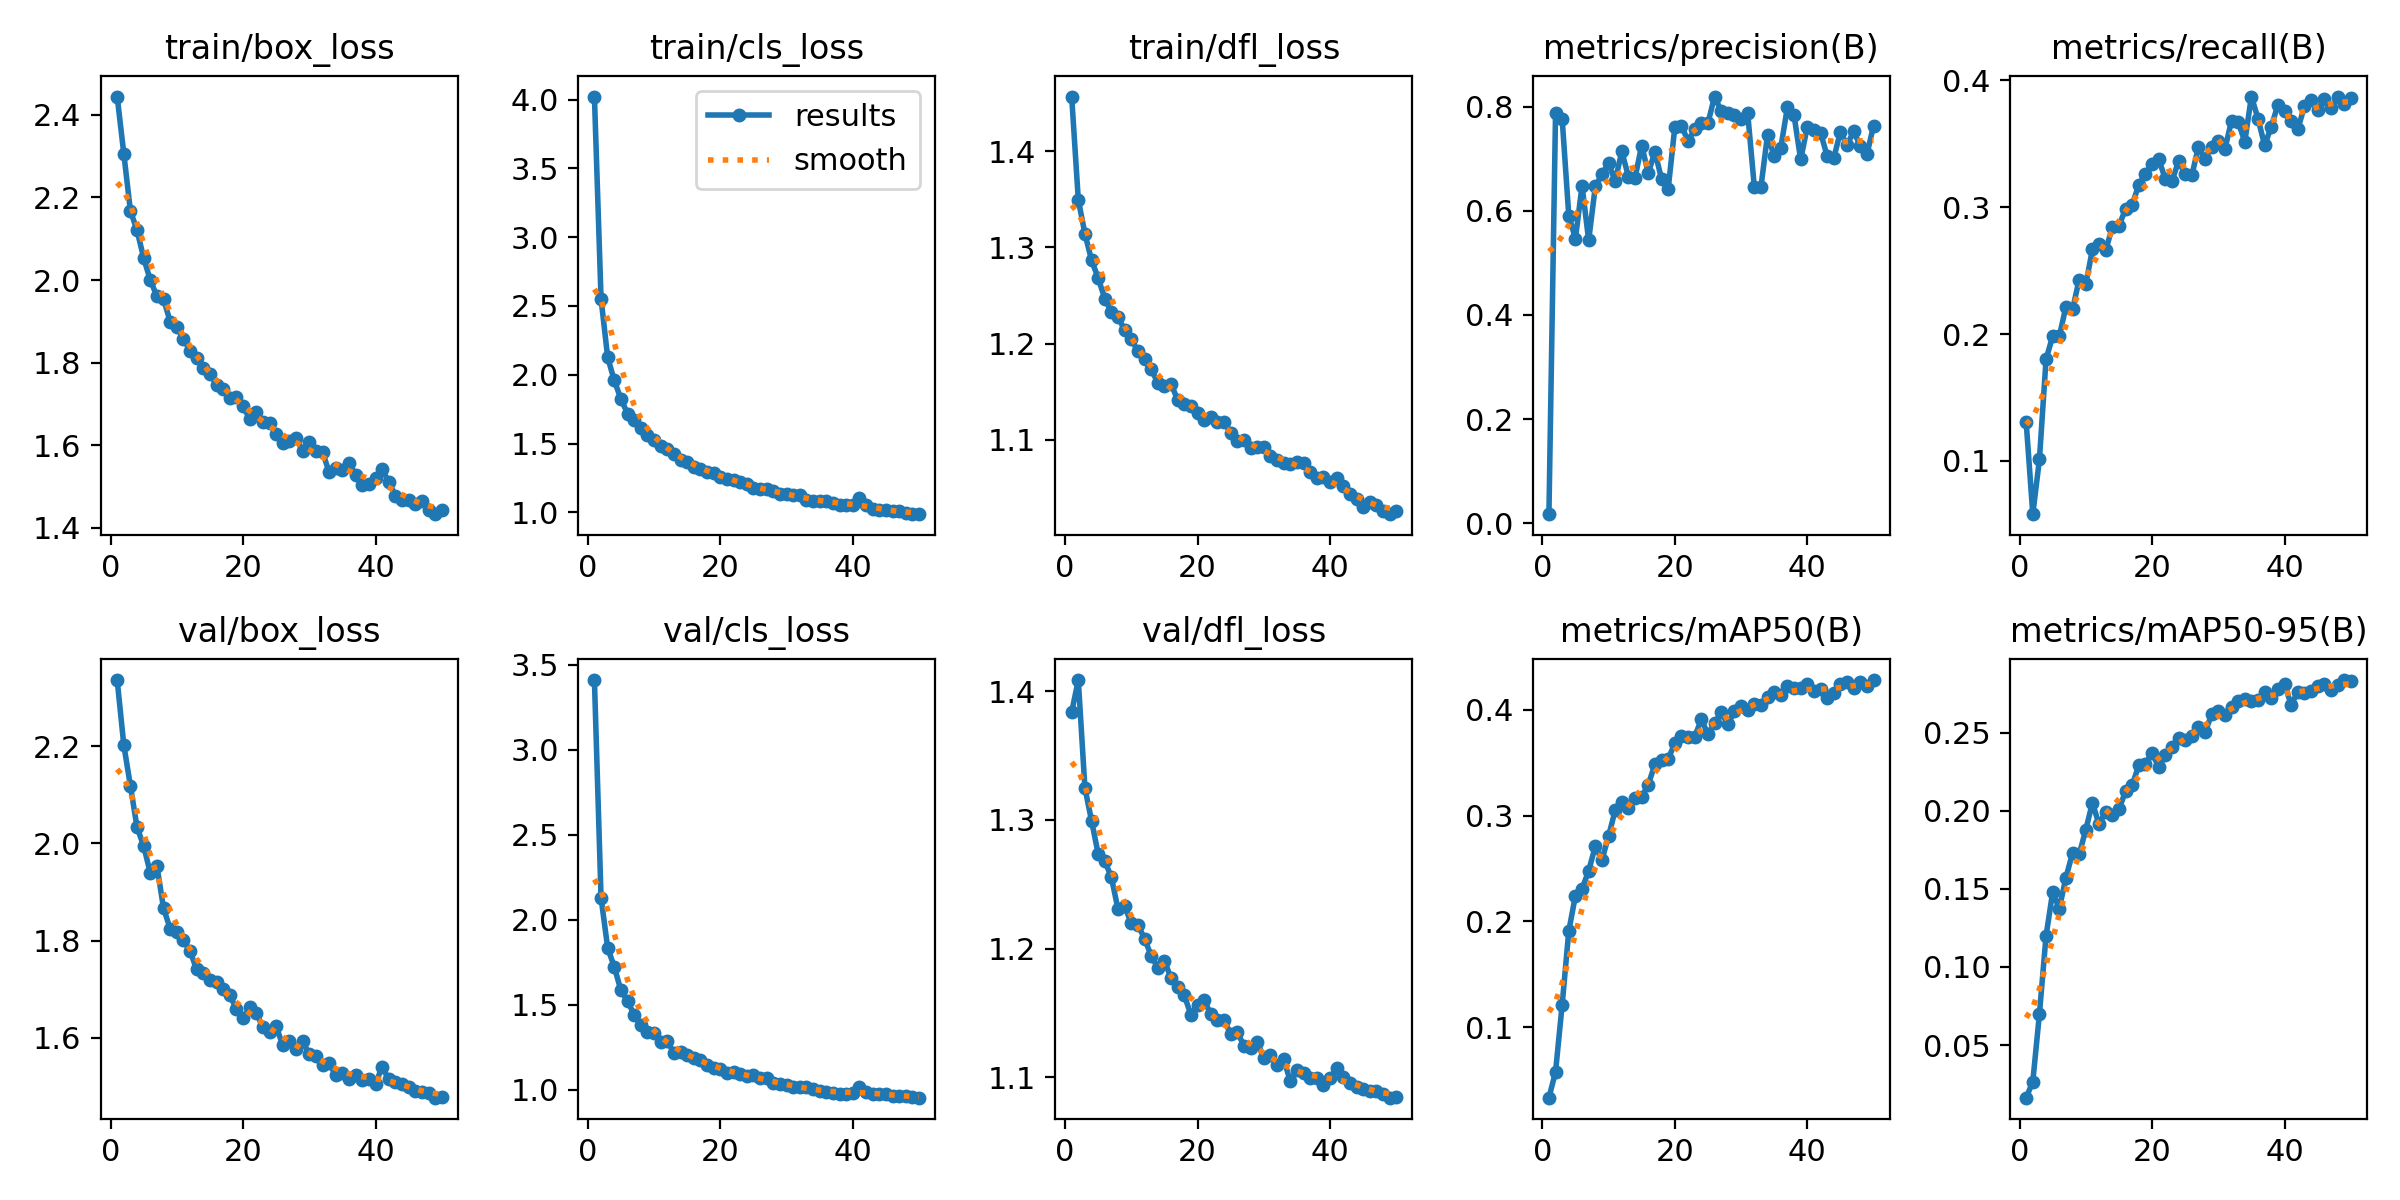

# Enhance YOLOv8 with training - Merge labels

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.axes import Axes
from typing import List, Tuple, Union
from PIL import Image
from matplotlib import cm
from matplotlib.colors import Colormap

from collections import defaultdict


YOLO_ANNOTATIONS_DIR = "/content/truckscene_annotations_yolo_format"
os.makedirs(YOLO_ANNOTATIONS_DIR, exist_ok=True)

category_map = {
    'human.pedestrian.adult': 0,
    'human.pedestrian.child': 1,
    'human.pedestrian.construction_worker': 2,
    'vehicle.bicycle': 3,
    'vehicle.motorcycle': 4,
    'vehicle.car': 5,
    'vehicle.emergency': 5,  # Accorpato a 'car'
    'vehicle.other': 5,      # Accorpato a 'car'
    'vehicle.truck': 6,
    'vehicle.trailer': 7,
    'vehicle.ego_trailer': 7,  # Accorpato a 'trailer'
    'vehicle.bus': 8,
    'vehicle.bus.rigid': 8,    # Accorpato a 'bus'
    'vehicle.construction': 9,
    'vehicle.train': 10,
    'static_object.traffic_sign': 11,
    'movable_object.trafficcone': 12,
    'movable_object.barrier': 12,  # Accorpato a 'traffic_cone/barrier'
    'animal': 13,
    # Rimosse o ignorate:
    # 'flat.driveable_surface'
    # 'static_object.building'
    # 'static_object.construction'
    # 'human.pedestrian.wheelchair'
    # 'human.pedestrian.stroller'
}

def project_point(K, point3D):
    X, Y, Z = point3D
    if Z <= 0:
        return None
    x = (K[0, 0] * X / Z) + K[0, 2]
    y = (K[1, 1] * Y / Z) + K[1, 2]
    return x, y


def save_yolo_annotation(boxes, image_path: str) -> None:

    #Camera intrinsic
    K = [ [640.0,0.0,960.0],
          [0.0,640.0,520.0],
          [0.0,0.0,1.0]]
    K = np.array(K)

    im = Image.open(image_path)
    img_w, img_h = im.size

    txt_filename = os.path.splitext(os.path.basename(image_path))[0] + ".txt"
    output_path = os.path.join(YOLO_ANNOTATIONS_DIR, txt_filename)

    with open(output_path, 'w') as f:
        for box in boxes:
            corners_3d = box.corners().T

            projected = [
                project_point(K, corner)
                for corner in corners_3d
            ]
            projected = [pt for pt in projected if pt is not None]

            if len(projected) == 0:
                continue

            xs = [x for x, y in projected]
            ys = [y for x, y in projected]

            x_min, x_max = np.clip(min(xs), 0, img_w), np.clip(max(xs), 0, img_w)
            y_min, y_max = np.clip(min(ys), 0, img_h), np.clip(max(ys), 0, img_h)

            #Convert the annotation format to YOLO
            x_center = (x_min + x_max) / 2 / img_w
            y_center = (y_min + y_max) / 2 / img_h
            width = (x_max - x_min) / img_w
            height = (y_max - y_min) / img_h

            class_id = category_map.get(box.name)
            if class_id is None:
                continue  # Ignora classi non presenti nella nuova mappa
            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")



for scene in trucksc.scene:
    scene_token = scene["token"]
    sample_token = scene['first_sample_token']
    while sample_token:
        sample = trucksc.get('sample', sample_token)
        for sensor_name, sensor_token in sample['data'].items():
            if not sensor_name.startswith("CAMERA"):
                continue

            sensor_data = trucksc.get('sample_data', sensor_token)
            image_path_rel = sensor_data['filename']
            image_path = os.path.join('/content/man-truckscenes', image_path_rel)

            data_path, boxes, _ = trucksc.get_sample_data(sensor_data['token'])
            save_yolo_annotation(boxes, data_path)


        sample_token = sample['next']


In [ ]:
import os
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

SOURCE_DIR = Path("/content/man-truckscenes/samples")
ANNOTATIONS_DIR = Path("/content/truckscene_annotations_yolo_format")
OUTPUT_DIR = Path("/content/truckscene_dataset_yolo_training")

image_extensions = {".jpg", ".jpeg", ".png"}

for folder in ["images/train", "images/val", "labels/train", "labels/val"]:
    (OUTPUT_DIR / folder).mkdir(parents=True, exist_ok=True)


camera_dirs = [d for d in SOURCE_DIR.iterdir() if d.is_dir() and d.name.startswith("CAMERA")]

all_images = []
for cam_dir in camera_dirs:
    imgs = [f for f in cam_dir.iterdir() if f.suffix.lower() in image_extensions and f.is_file()]
    all_images.extend(imgs)

print(f"Totale immagini trovate: {len(all_images)}")


train_imgs, val_imgs = train_test_split(all_images, test_size=0.2, random_state=42)
def copy_files(img_list, split):
    for img_path in img_list:
        dest_img = OUTPUT_DIR / f"images/{split}" / img_path.name
        try:
            shutil.copy(img_path, dest_img)
        except Exception as e:
            print(f"Errore copia immagine {img_path}: {e}")

        txt_name = img_path.with_suffix('.txt').name
        src_txt = ANNOTATIONS_DIR / txt_name
        if src_txt.exists():
            dest_txt = OUTPUT_DIR / f"labels/{split}" / txt_name
            try:
                shutil.copy(src_txt, dest_txt)
            except Exception as e:
                print(f"Errore copia annotazione {src_txt}: {e}")
        else:
            print(f"Annotazione mancante per {img_path.name}")

copy_files(train_imgs, "train")
copy_files(val_imgs, "val")

print("Completato")


In [ ]:
import yaml

data = {
    "train": "/content/truckscene_dataset_yolo_training/images/train",
    "val": "/content/truckscene_dataset_yolo_training/images/val",
    "nc": 14,
    "names": [
        'pedestrian_adult',
        'pedestrian_child',
        'pedestrian_construction_worker',
        'bicycle',
        'motorcycle',
        'car',
        'truck',
        'trailer',
        'bus',
        'construction_vehicle',
        'train',
        'traffic_sign',
        'traffic_cone',
        'animal'
    ]
}

with open("data.yaml", "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("File data.yaml creato.")


Il file data.yaml deve essere messo all'interno di "content/truckscene_dataset_yolo_training"

In [ ]:
!yolo train model=yolov8n.pt data=/content/truckscene_dataset_yolo_training/data.yaml epochs=100 freeze=5

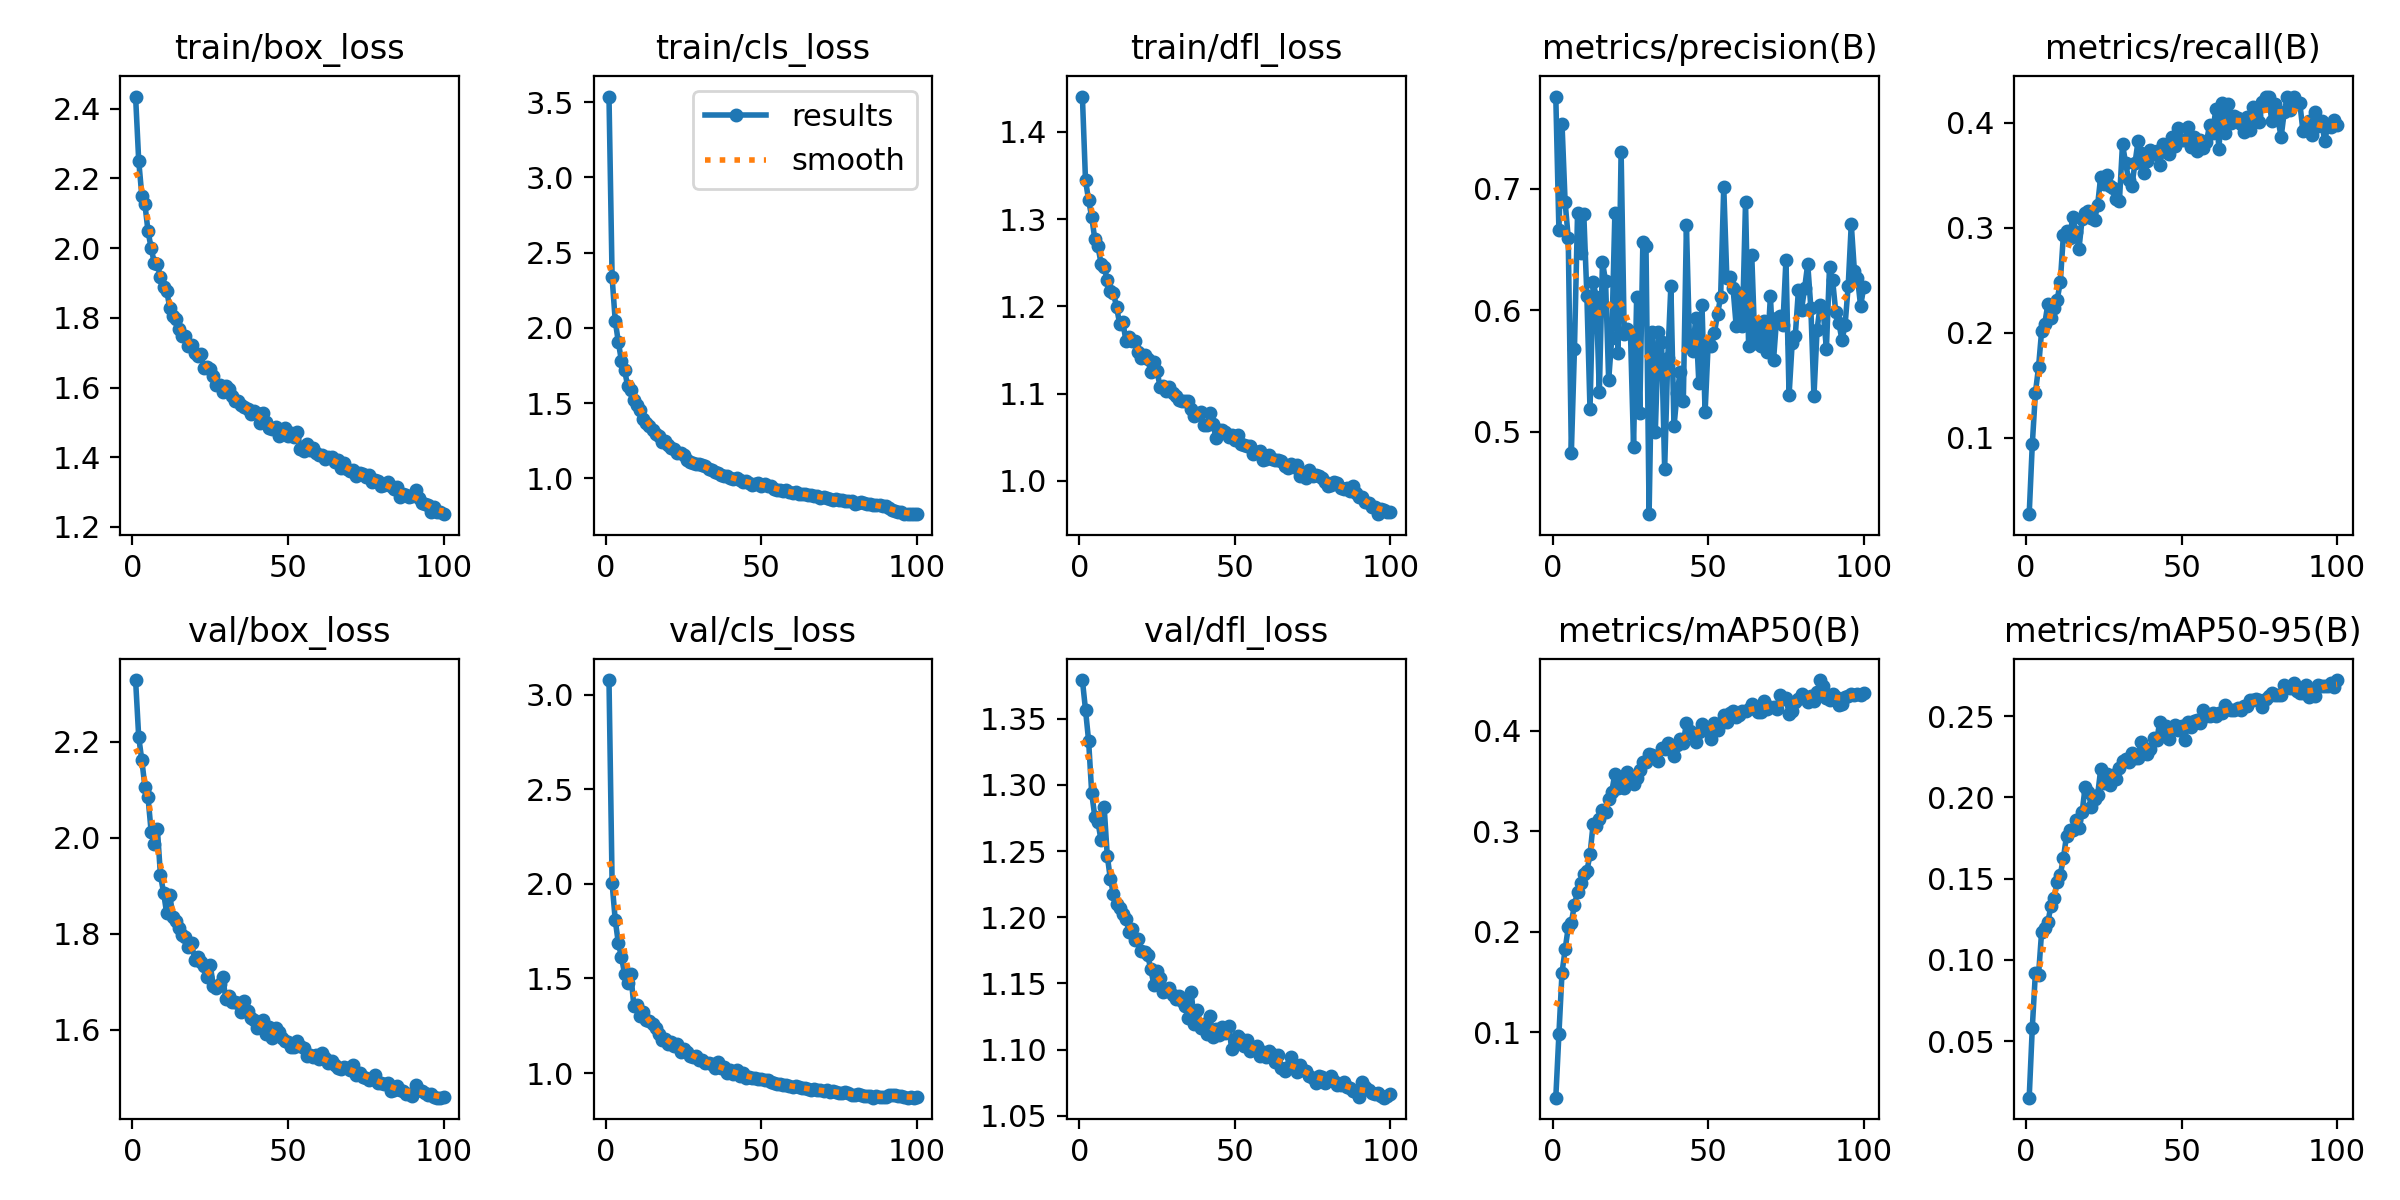

# Second inference - trained YOLO with MAN TruckScenes labels

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.axes import Axes
from typing import List, Tuple, Union
from PIL import Image
from matplotlib import cm
from matplotlib.colors import Colormap
from truckscenes.utils.geometry_utils import BoxVisibility

from collections import defaultdict

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = max(0, boxA[2] - boxA[0]) * max(0, boxA[3] - boxA[1])
    boxBArea = max(0, boxB[2] - boxB[0]) * max(0, boxB[3] - boxB[1])

    if boxAArea + boxBArea - interArea == 0:
        return 0.0
    return interArea / float(boxAArea + boxBArea - interArea)

TP, FP, FN = 0, 0, 0
iou_threshold = 0.5
# Define output folders
YOLO_ANNOTATIONS_DIR = "/content/truckscene_annotations_yolo_format"
os.makedirs(YOLO_ANNOTATIONS_DIR, exist_ok=True)

IMAGES_OUTPUT_DIR = "/content/truckscene_rendered_images"
os.makedirs(IMAGES_OUTPUT_DIR, exist_ok=True)



def map_category_to_yolo_id(category_name: str) -> int:
    category_map = {
        'human.pedestrian.adult': 0,
        'vehicle.bicycle': 1,
        'vehicle.car': 2,
        'vehicle.motorcycle': 3,
        'vehicle.emergency': 4,
        'vehicle.bus': 5,
        'vehicle.train':6,
        'vehicle.truck': 7,
        'vehicle.trailer':8,
        'vehicle.ego_trailer':9,
        'vehicle.construction':10,
        'static_object.traffic_sign':11,
        'static_object.building': 12,
        'static_object.construction': 13,
        'movable_object.trafficcone': 14,
        'movable_object.barrier': 15,
        'animal': 16,
        'flat.driveable_surface':17,
        'vehicle.other':18,
        'human.pedestrian.wheelchair': 19,
        'human.pedestrian.stroller': 20,
        'human.pedestrian.child':21,
        'human.pedestrian.construction_worker':22,
        'vehicle.bus.rigid': 23
    }
    for key, val in category_map.items():
        if category_name.lower() in key.lower():
            return val
    return -1


def render_box(box, axis: Axes, view: np.ndarray = np.eye(3), normalize: bool = False,
               color='r', linewidth: float = 2) -> None:
    from truckscenes.utils.visualization_utils import view_points  # Assumo che esista questa funzione
    corners_2d = view_points(box.corners(), view, normalize=normalize)[:2, :]
    u_min, v_min = np.min(corners_2d, axis=1)
    u_max, v_max = np.max(corners_2d, axis=1)
    axis.add_patch(Rectangle((u_min, v_min), u_max-u_min, v_max-v_min,
                             linewidth=linewidth, edgecolor=color, facecolor='none'))

def render_camera_sample_data(trucksc,
                              sample_data_token: str,
                              yolo_results,
                              with_anns: bool = True,
                              selected_anntokens: List[str] = None,
                              box_vis_level = None,
                              ax: Axes = None) -> None:
    data_path, boxes, camera_intrinsic = trucksc.get_sample_data(
        sample_data_token, box_vis_level=box_vis_level,
        selected_anntokens=selected_anntokens
    )
    data = Image.open(data_path)
    if ax is None:
        fig, ax = plt.subplots(1,1,figsize=(12,8))

    ax.imshow(data)

    if with_anns:
        for box in boxes:
            c = np.array(get_color(trucksc, box.name)) / 255.0
            render_box(box, ax, view=camera_intrinsic, normalize=True,
                       color='r', linewidth=1.0)


    # Render YOLO predictions
    for box in yolo_results.boxes:
        xyxy = box.xyxy[0].tolist()
        xmin, ymin, xmax, ymax = xyxy
        width = xmax - xmin
        height = ymax - ymin
        rect = Rectangle((xmin, ymin), width, height, linewidth=2,
                         edgecolor='green', facecolor='none')
        ax.add_patch(rect)

    ax.set_xlim(0, data.size[0])
    ax.set_ylim(data.size[1], 0)
    ax.axis('off')

def render_sample_data(trucksc,
                       sample_data_token: str,
                       results_yolo,
                       with_anns: bool = True,
                       selected_anntokens: List[str] = None,
                       box_vis_level = None,
                       axes_limit: Union[List[float], Tuple[float], float] = 40,
                       ax: Axes = None,
                       out_path: str = None) -> None:

    if not isinstance(sample_data_token, list):
        sample_data_token = [sample_data_token]

    sensor_modality = trucksc.get('sample_data', sample_data_token[0])['sensor_modality']

    if sensor_modality == 'camera':
        if ax is None:
            _, ax = plt.subplots(1, 1, figsize=(9, 16))
        render_camera_sample_data(trucksc, sample_data_token[0], results_yolo,
                                  with_anns, selected_anntokens, box_vis_level, ax)
    else:
        raise NotImplementedError("Solo camera modality supportata")

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        plt.savefig(out_path, bbox_inches='tight', pad_inches=0, transparent=True, dpi=300)
        plt.close()

def get_color(trucksc, category_name: str) -> Tuple[int, int, int]:
    return trucksc.colormap[category_name]


import json
import gc

start_scene_token = None
start_sample_token = None
resume = False

#Progress file used in case the runtime is disconnected
PROGRESS_FILE = "/content/progress.json"
progress = {}
if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE, "r") as f:
        progress = json.load(f)
        TP = progress.get("TP", 0)
        FP = progress.get("FP", 0)
        FN = progress.get("FN", 0)
        start_scene_token = progress.get("scene_token")
        start_sample_token = progress.get("sample_token")
        resume = start_scene_token is not None

det_model = YOLO('/content/runs/detect/train2/weights/best.pt')
for scene in trucksc.scene:
    scene_token = scene["token"]

    if resume and scene_token != start_scene_token:
          continue
    resume = False

    sample_token = scene['first_sample_token']
    while sample_token:
        if start_sample_token:
              if sample_token != start_sample_token:
                  sample_token = trucksc.get("sample", sample_token)["next"]
                  continue
              start_sample_token = None

        sample = trucksc.get('sample', sample_token)
        for sensor_name, sensor_token in sample['data'].items():
            if not sensor_name.startswith("CAMERA"):
                continue

            sensor_data = trucksc.get('sample_data', sensor_token)
            image_path_rel = sensor_data['filename']
            image_path = os.path.join('/content/man-truckscenes', image_path_rel)


            results_det = det_model(image_path)[0]


            data_path, boxes, _ = trucksc.get_sample_data(sensor_data['token'])



            output_image_path = os.path.join(IMAGES_OUTPUT_DIR,
                                             os.path.splitext(os.path.basename(image_path))[0] + "_rendered.png")
            render_sample_data(trucksc, sensor_data['token'], results_det, out_path=output_image_path, box_vis_level=BoxVisibility.ANY)


            data_path, boxes, cam_intrinsic = trucksc.get_sample_data(sensor_data['token'])


            #Compute accuracy - comparison between Ground Truth and YOLO predictions
            gt_boxes = []
            for box in boxes:
                corners_2d = view_points(box.corners(), cam_intrinsic, normalize=True)[:2, :]
                x_min, y_min = np.min(corners_2d,axis=1)
                x_max, y_max = np.max(corners_2d,axis=1)

                x=x_min
                y=y_min
                width = x_max - x_min
                height = y_max - y_min
                print(f"GT-BOX:{[x, y, x+width, y+height]}")
                class_id = map_category_to_yolo_id(box.name)
                if class_id == -1:
                    continue
                gt_boxes.append({
                    "bbox": [x, y, x+width, y+height],
                    "class": class_id
                })

            pred_boxes = []
            for box in results_det.boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                class_id = int(box.cls[0])
                score = float(box.conf[0])
                print(f"YOLO-BOX:{[x1,y1,x2,y2]}")
                pred_boxes.append({
                    "bbox": [x1, y1, x2, y2],
                    "class": class_id,
                    "score": score
                })

            matched_gt = set()
            for pred in pred_boxes:
                best_iou = 0
                best_gt = None
                for i, gt in enumerate(gt_boxes):
                    if i in matched_gt or pred['class'] != gt['class']:
                        continue
                    iou = compute_iou(pred['bbox'], gt['bbox'])
                    if iou > best_iou:
                        best_iou = iou
                        best_gt = i
                if best_iou >= iou_threshold:
                    TP += 1
                    matched_gt.add(best_gt)
                else:
                    FP += 1

            FN += len(gt_boxes) - len(matched_gt)

            # Save status into progress.json file
            with open(PROGRESS_FILE, "w") as f:
                json.dump({"scene_token": scene_token, "sample_token": sample_token,"TP": TP,"FP": FP,"FN": FN}, f)

            # Clean up RAM
            del boxes, results_det, gt_boxes, pred_boxes
            gc.collect()



        sample_token = sample['next']

# Compute statistics
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1_score:.4f}")
print(f"TP: {TP}, FP: {FP}, FN: {FN}")



Precision: 0.5941
Recall:    0.2636
F1 Score:  0.3652
TP: 7391, FP: 5049, FN: 20649

# Third inference - trained YOLOv8 with merged labels

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.axes import Axes
from typing import List, Tuple, Union
from PIL import Image
from matplotlib import cm
from matplotlib.colors import Colormap
from truckscenes.utils.geometry_utils import BoxVisibility

from collections import defaultdict

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = max(0, boxA[2] - boxA[0]) * max(0, boxA[3] - boxA[1])
    boxBArea = max(0, boxB[2] - boxB[0]) * max(0, boxB[3] - boxB[1])

    if boxAArea + boxBArea - interArea == 0:
        return 0.0
    return interArea / float(boxAArea + boxBArea - interArea)

TP, FP, FN = 0, 0, 0
iou_threshold = 0.5
# Define output folders
YOLO_ANNOTATIONS_DIR = "/content/truckscene_annotations_yolo_format"
os.makedirs(YOLO_ANNOTATIONS_DIR, exist_ok=True)

IMAGES_OUTPUT_DIR = "/content/truckscene_rendered_images"
os.makedirs(IMAGES_OUTPUT_DIR, exist_ok=True)



def map_category_to_yolo_id(category_name: str) -> int:
    category_map = {
    'human.pedestrian.adult': 0,
    'human.pedestrian.child': 1,
    'human.pedestrian.construction_worker': 2,
    'vehicle.bicycle': 3,
    'vehicle.motorcycle': 4,
    'vehicle.car': 5,
    'vehicle.emergency': 5,  # Accorpato a 'car'
    'vehicle.other': 5,      # Accorpato a 'car'
    'vehicle.truck': 6,
    'vehicle.trailer': 7,
    'vehicle.ego_trailer': 7,  # Accorpato a 'trailer'
    'vehicle.bus': 8,
    'vehicle.bus.rigid': 8,    # Accorpato a 'bus'
    'vehicle.construction': 9,
    'vehicle.train': 10,
    'static_object.traffic_sign': 11,
    'movable_object.trafficcone': 12,
    'movable_object.barrier': 12,  # Accorpato a 'traffic_cone/barrier'
    'animal': 13,
    # Rimosse o ignorate:
    # 'flat.driveable_surface'
    # 'static_object.building'
    # 'static_object.construction'
    # 'human.pedestrian.wheelchair'
    # 'human.pedestrian.stroller'
}

    for key, val in category_map.items():
        if category_name.lower() in key.lower():
            return val
    return -1


def render_box(box, axis: Axes, view: np.ndarray = np.eye(3), normalize: bool = False,
               color='r', linewidth: float = 2) -> None:
    from truckscenes.utils.visualization_utils import view_points  # Assumo che esista questa funzione
    corners_2d = view_points(box.corners(), view, normalize=normalize)[:2, :]
    u_min, v_min = np.min(corners_2d, axis=1)
    u_max, v_max = np.max(corners_2d, axis=1)
    axis.add_patch(Rectangle((u_min, v_min), u_max-u_min, v_max-v_min,
                             linewidth=linewidth, edgecolor=color, facecolor='none'))

def render_camera_sample_data(trucksc,
                              sample_data_token: str,
                              yolo_results,
                              with_anns: bool = True,
                              selected_anntokens: List[str] = None,
                              box_vis_level = None,
                              ax: Axes = None) -> None:
    data_path, boxes, camera_intrinsic = trucksc.get_sample_data(
        sample_data_token, box_vis_level=box_vis_level,
        selected_anntokens=selected_anntokens
    )
    data = Image.open(data_path)
    if ax is None:
        fig, ax = plt.subplots(1,1,figsize=(12,8))

    ax.imshow(data)

    if with_anns:
        for box in boxes:
            c = np.array(get_color(trucksc, box.name)) / 255.0
            render_box(box, ax, view=camera_intrinsic, normalize=True,
                       color='r', linewidth=1.0)


    # Render YOLO predictions
    for box in yolo_results.boxes:
        xyxy = box.xyxy[0].tolist()
        xmin, ymin, xmax, ymax = xyxy
        width = xmax - xmin
        height = ymax - ymin
        rect = Rectangle((xmin, ymin), width, height, linewidth=2,
                         edgecolor='green', facecolor='none')
        ax.add_patch(rect)

    ax.set_xlim(0, data.size[0])
    ax.set_ylim(data.size[1], 0)
    ax.axis('off')

def render_sample_data(trucksc,
                       sample_data_token: str,
                       results_yolo,
                       with_anns: bool = True,
                       selected_anntokens: List[str] = None,
                       box_vis_level = None,
                       axes_limit: Union[List[float], Tuple[float], float] = 40,
                       ax: Axes = None,
                       out_path: str = None) -> None:

    if not isinstance(sample_data_token, list):
        sample_data_token = [sample_data_token]

    sensor_modality = trucksc.get('sample_data', sample_data_token[0])['sensor_modality']

    if sensor_modality == 'camera':
        if ax is None:
            _, ax = plt.subplots(1, 1, figsize=(9, 16))
        render_camera_sample_data(trucksc, sample_data_token[0], results_yolo,
                                  with_anns, selected_anntokens, box_vis_level, ax)
    else:
        raise NotImplementedError("Solo camera modality supportata")

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        plt.savefig(out_path, bbox_inches='tight', pad_inches=0, transparent=True, dpi=300)
        plt.close()

def get_color(trucksc, category_name: str) -> Tuple[int, int, int]:
    return trucksc.colormap[category_name]


import json
import gc

start_scene_token = None
start_sample_token = None
resume = False

#Progress file used in case the runtime is disconnected
PROGRESS_FILE = "/content/progress.json"
progress = {}
if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE, "r") as f:
        progress = json.load(f)
        TP = progress.get("TP", 0)
        FP = progress.get("FP", 0)
        FN = progress.get("FN", 0)
        start_scene_token = progress.get("scene_token")
        start_sample_token = progress.get("sample_token")
        resume = start_scene_token is not None

det_model = YOLO('/content/runs/detect/train2/weights/best.pt')
for scene in trucksc.scene:
    scene_token = scene["token"]

    if resume and scene_token != start_scene_token:
          continue
    resume = False

    sample_token = scene['first_sample_token']
    while sample_token:
        if start_sample_token:
              if sample_token != start_sample_token:
                  sample_token = trucksc.get("sample", sample_token)["next"]
                  continue
              start_sample_token = None

        sample = trucksc.get('sample', sample_token)
        for sensor_name, sensor_token in sample['data'].items():
            if not sensor_name.startswith("CAMERA"):
                continue

            sensor_data = trucksc.get('sample_data', sensor_token)
            image_path_rel = sensor_data['filename']
            image_path = os.path.join('/content/man-truckscenes', image_path_rel)


            results_det = det_model(image_path)[0]


            data_path, boxes, _ = trucksc.get_sample_data(sensor_data['token'])



            output_image_path = os.path.join(IMAGES_OUTPUT_DIR,
                                             os.path.splitext(os.path.basename(image_path))[0] + "_rendered.png")
            render_sample_data(trucksc, sensor_data['token'], results_det, out_path=output_image_path, box_vis_level=BoxVisibility.ANY)


            data_path, boxes, cam_intrinsic = trucksc.get_sample_data(sensor_data['token'])


            #Compute accuracy - comparison between Ground Truth and YOLO predictions
            gt_boxes = []
            for box in boxes:
                corners_2d = view_points(box.corners(), cam_intrinsic, normalize=True)[:2, :]
                x_min, y_min = np.min(corners_2d,axis=1)
                x_max, y_max = np.max(corners_2d,axis=1)

                x=x_min
                y=y_min
                width = x_max - x_min
                height = y_max - y_min
                print(f"GT-BOX:{[x, y, x+width, y+height]}")
                class_id = map_category_to_yolo_id(box.name)
                if class_id is None:
                    continue  # Ignora classi non presenti nella nuova mappa

                gt_boxes.append({
                    "bbox": [x, y, x+width, y+height],
                    "class": class_id
                })

            pred_boxes = []
            for box in results_det.boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                class_id = int(box.cls[0])
                score = float(box.conf[0])
                print(f"YOLO-BOX:{[x1,y1,x2,y2]}")
                pred_boxes.append({
                    "bbox": [x1, y1, x2, y2],
                    "class": class_id,
                    "score": score
                })

            matched_gt = set()
            for pred in pred_boxes:
                best_iou = 0
                best_gt = None
                for i, gt in enumerate(gt_boxes):
                    if i in matched_gt or pred['class'] != gt['class']:
                        continue
                    iou = compute_iou(pred['bbox'], gt['bbox'])
                    if iou > best_iou:
                        best_iou = iou
                        best_gt = i
                if best_iou >= iou_threshold:
                    TP += 1
                    matched_gt.add(best_gt)
                else:
                    FP += 1

            FN += len(gt_boxes) - len(matched_gt)

            # Save status into progress.json file
            with open(PROGRESS_FILE, "w") as f:
                json.dump({"scene_token": scene_token, "sample_token": sample_token,"TP": TP,"FP": FP,"FN": FN}, f)

            # Clean up RAM
            del boxes, results_det, gt_boxes, pred_boxes
            gc.collect()



        sample_token = sample['next']

# Compute statistics
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1_score:.4f}")
print(f"TP: {TP}, FP: {FP}, FN: {FN}")



Precision: 0.6530
Recall:    0.3308
F1 Score:  0.4392
TP: 11891, FP: 6318, FN: 24054

# Use of trained models

In this part it is possible just to run the trained models, uploading the trained models from the GitHub.

In [ ]:
%%bash
# For v1.0 version of mini dataset
wget https://man-truckscenes.s3.eu-central-1.amazonaws.com/release/mini/man-truckscenes_metadata_v1.0-mini.zip
wget https://man-truckscenes.s3.eu-central-1.amazonaws.com/release/mini/man-truckscenes_sensordata_v1.0-mini.zip
unzip "man-truckscenes_*.zip"

In [ ]:
!pip install ultralytics
from ultralytics import YOLO
import os

In [ ]:
!git clone https://github.com/FrancescoPassiatore/ObjectDetection-Camera-Lidar-fusion.git

1) Running trained YOLOv8n on MAN Truckscenes labels

In [ ]:

# Upload model
model = YOLO("/content/ObjectDetection-Camera-Lidar-fusion/trained_models/YOLOv8_MAN_labels.pt")

root_dir = "/content/man-truckscenes/samples"

camera_dirs = [os.path.join(root_dir, d) for d in os.listdir(root_dir) if d.startswith("CAMERA")]

#Shows annotation with confidence > 0.3 , this can be changed
for cam_dir in camera_dirs:
    print(f"Running prediction on: {cam_dir}")
    model.predict(
        source=cam_dir,
        conf=0.3,
        save=True,
        save_txt=True,
        project="runs/predict",
        name=os.path.basename(cam_dir)
    )



2) Runnning of trained YOLOv8n on merged labels

In [ ]:

# Upload model
model = YOLO("/content/ObjectDetection-Camera-Lidar-fusion/trained_models/YOLOv8_merged.pt")

root_dir = "/content/man-truckscenes/samples"

camera_dirs = [os.path.join(root_dir, d) for d in os.listdir(root_dir) if d.startswith("CAMERA")]

#Shows annotation with confidence > 0.3 , this can be changed
for cam_dir in camera_dirs:
    print(f"Running prediction on: {cam_dir}")
    model.predict(
        source=cam_dir,
        conf=0.3,
        save=True,
        save_txt=True,
        project="runs/predict",
        name=os.path.basename(cam_dir)
    )

